In [1]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [55]:
def attenuation(i, j, mu=0.2, model="none"):
    """
    Vrne oslabitveni faktor za dozo v celici (i, j) glede na izbrani model.

    Parameters:
        i (int): vrstica (za vertikalne žarke)
        j (int): stolpec (za horizontalne žarke)
        mu (float): koeficient pojemanja (za eksponentni model)
        model (str): "none" | "exp" | "proton"

    Returns:
        tuple: (horizontal_attenuation, vertical_attenuation)
    """
    if model == "none":
        return 1.0, 1.0
    
    elif model == "exp":
        return np.exp(-mu * j), np.exp(-mu * i)
    
    elif model == "proton":
        # Preprost približek Braggovega vrha – največja doza na določeni globini
        def bragg(depth, peak=2):
            if depth < peak:
                return (depth / peak) ** 2
            else:
                return np.exp(-3 * (depth - peak))
        return bragg(j), bragg(i)
    
    else:
        raise ValueError(f"Neznan model pojemanja: {model}")


def optimize_dose(cells, mode=1, mu=0.3, atten_model="none"):
    """
    Optimizira razporeditev žarkov v radioterapiji.

    Parameters:
        cells (list of list of bool): Mreža celic (True = tumor, False = zdravo)
        mode (int):
            1 - tumor ≥ 1, zdravo minimalno
            2 - zdravo ≤ 1, tumor maksimalno
        mu (float): pojemkovni koeficient za eksponentni model
        atten_model (str): "none" | "exp" | "proton"

    Returns:
        scipy.optimize.OptimizeResult
    """
    cells = np.array(cells)
    n_rows, n_cols = cells.shape
    n_vars = n_rows + n_cols  # h0...hn-1, v0...vm-1

    A = []
    b = []
    c = np.zeros(n_vars)

    for i in range(n_rows):
        for j in range(n_cols):
            h_att, v_att = attenuation(i, j, mu=mu, model=atten_model)
            row = np.zeros(n_vars)
            row[i] = h_att
            row[n_rows + j] = v_att

            if mode == 1:
                if cells[i, j]:  # tumor
                    A.append(-row)
                    b.append(-1)
                else:
                    c[i] += h_att
                    c[n_rows + j] += v_att
            elif mode == 2:
                if cells[i, j]:  # tumor
                    c[i] -= h_att
                    c[n_rows + j] -= v_att
                else:
                    A.append(row)
                    b.append(1)

    bounds = [(0, None)] * n_vars
    result = linprog(c=c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

    # ⬇️ Compute actual dose matrix using attenuation
    dose_grid = np.zeros((n_rows, n_cols))
    if result.success:
        h_vals = result.x[:n_rows]
        v_vals = result.x[n_rows:]
        for i in range(n_rows):
            for j in range(n_cols):
                h_att, v_att = attenuation(i, j, mu=mu, model=atten_model)
                dose_grid[i, j] = h_vals[i] * h_att + v_vals[j] * v_att

    return result, dose_grid


def visualize_dose(cells, dose_grid):
    """
    Prikaže toplotno karto (heatmap) doz po mreži celic, z obrobo in šrafuro okrog tumorskih celic.

    Parameters:
        cells (list of list of bool): Mreža celic (True = tumor)
        dose_grid (2D array): Matrika prejete doze po celicah
    """
    cells = np.array(cells)
    n_rows, n_cols = cells.shape

    fig, ax = plt.subplots(figsize=(8, 5))
    c = ax.imshow(dose_grid, cmap='Reds', interpolation='nearest')

    # Dodaj obrobe in šrafuro za tumorske celice
    for i in range(n_rows):
        for j in range(n_cols):
            if cells[i, j]:  # tumor
                rect = patches.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    linewidth=2,
                    edgecolor='gray',
                    facecolor='none',
                    hatch='///'
                )
                ax.add_patch(rect)

    # Dodaj vrednosti v celice
    for i in range(n_rows):
        for j in range(n_cols):
            val = f"{dose_grid[i, j]:.2f}"
            ax.text(j, i, val, ha='center', va='center', color='white', fontsize=8)

    ax.set_title("Toplotna karta prejetih doz")
    plt.colorbar(c, label="Doza")
    plt.xticks(np.arange(n_cols), labels=[f"v{j}" for j in range(n_cols)])
    plt.yticks(np.arange(n_rows), labels=[f"h{i}" for i in range(n_rows)])
    plt.xlabel("Vertikalna smer")
    plt.ylabel("Horizontalna smer")
    plt.tight_layout()
    plt.show()


Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimalna vrednost: 14.9657778479304
Horizontalni žarki (h): [0.         0.         1.22140276 1.22140276 1.40342213 0.        ]
Vertikalni žarki (v): [0.         0.         1.22140276 1.22140276 0.8221188  1.07651607
 0.        ]


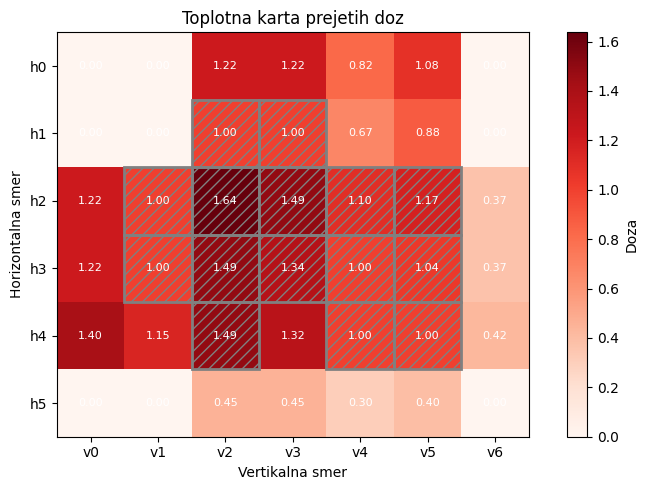

In [59]:
cells = [
    [False, False, False, False, False, False, False],
    [False, False, True,  True,  False, False, False],
    [False, True,  True,  True,  True,  True,  False],
    [False, True,  True,  True,  True,  True,  False],
    [False, False, True,  False, True,  True,  False],
    [False, False, False, False, False, False, False]
]

res, dose_grid = optimize_dose(cells, mode=1, mu=0.2, atten_model="exp")

print("Status:", res.message)
print("Optimalna vrednost:", res.fun)

# Razbij spremenljivke na h in v
n_rows = len(cells)
n_cols = len(cells[0])

h = res.x[:n_rows]
v = res.x[n_rows:]

print("Horizontalni žarki (h):", h)
print("Vertikalni žarki (v):", v)

visualize_dose(cells, dose_grid)